# Vusalization Generation - GFW & ASTD over time
The notebook visualize and export visualization of tracks

- Video
- Image
- Image zoomed


### Imports


In [1]:
import os
import pandas as pd
import numpy as np
import track_builder as tb
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import matplotlib.animation as animation
from tqdm.notebook import tqdm
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from IPython.display import Image, display

gfw_2020_path = "D:/Stockage/GFW/"
astd_path = r"D:\Stockage\ASTD"
parquet_path = "../../examples/data/"

months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Periods for load_periods
periods = {
    2019: months,
    2020: months
}

### Load data

In [2]:
def load_data_gfw(parquet_file, source, periods):
    parquet_file = parquet_path + parquet_file

    if os.path.exists(parquet_file):
        data = pd.read_parquet(parquet_file)
        print(f"Loaded data {parquet_file}, parameters ignored")
    else:
        dfs = []
        for group_year in os.listdir(source):
            parts = group_year.split("-")
            if parts[0] != "mmsi":
                continue

            file_year = int(parts[-1])

            if file_year in periods:
                print("Working with :", group_year)
                for file in os.listdir(source + group_year):
                    if file.endswith(".csv"):
                        month = int(file.split("-")[6])

                        if periods[file_year] is None or month in periods[file_year]:
                            path = os.path.join(source + group_year, file)
                            df = pd.read_csv(path)
                            dfs.append(df)

        if not dfs:
            raise ValueError("No matching CSV files found")

        data = pd.concat(dfs, ignore_index=True)
        data.to_parquet(parquet_file)
        print(f"Saved data to {parquet_file}")

    return data

def load_periods(parquet_file, source, periods, **kwargs):
    parquet_file = parquet_path + parquet_file
    if os.path.exists(parquet_file):
        period =  pd.read_parquet(parquet_file)
        print(f"Loaded period {parquet_file}, parameters ignored")
    else:
        period = tb.load_astd_periods(base_path=source, periods=periods, **kwargs)
        period.to_parquet(parquet_file)
        print(f"Loaded period {parquet_file} from {source}")

    return period

In [3]:
df_ASTD_2020 = load_periods('all_segments_periods2019_2020.parquet', source=astd_path, periods= periods, remove_nan_rows="default", usecols="default", progress=True)
df_ASTD_2020 = df_ASTD_2020[df_ASTD_2020['astd_cat'].str.contains('Fishing vessels')].copy()
df_ASTD_2020["date_time_utc"] = pd.to_datetime(df_ASTD_2020["date_time_utc"])
display(df_ASTD_2020)

df_GFW_2020 = load_data_gfw('gfw_2019_2020.parquet', source=gfw_2020_path, periods = periods)
df_GFW_2020['date'] = pd.to_datetime(df_GFW_2020['date'])
display(df_GFW_2020)

Loaded period ../../examples/data/all_segments_periods2019_2020.parquet, parameters ignored


,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude
3,1892,2019-01-01 00:00:04+00:00,Russia,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.028629,540,29.700306,70.626442
4,3009,2019-01-01 00:00:04+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1945.192749,371,25.147583,70.990837
7,2946,2019-01-01 00:00:05+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.057516,119,-23.244274,66.155754
11,3034,2019-01-01 00:00:08+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,3.720555,100,-13.740026,65.135429
17,3107,2019-01-01 00:00:14+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.718225,170,-23.810671,64.921066
...,...,...,...,...,...,...,...,...,...,...
85472769,1634,2020-12-31 23:59:51+00:00,Russia,FS Ice Class 1B,Fishing vessels,1000 - 4999 GT,1627.817993,364,10.828934,77.686615
85472770,2113,2020-12-31 23:59:51+00:00,Norway,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,993.163025,369,17.505766,74.173950
85472771,70,2020-12-31 23:59:51+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.551000,360,-22.718353,64.037857
85472774,1199,2020-12-31 23:59:54+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.849000,661,-22.425282,63.839603


Loaded data ../../examples/data/gfw_2019_2020.parquet, parameters ignored


,date,cell_ll_lat,cell_ll_lon,mmsi,hours,fishing_hours
0,2019-01-01,-74.6,-106.5,440347000,0.8363,0.5983
1,2019-01-01,-74.6,-106.3,440347000,0.2288,0.0000
2,2019-01-01,-74.6,-105.7,440347000,0.2599,0.2599
3,2019-01-01,-74.6,-106.4,440347000,0.3008,0.0000
4,2019-01-01,-74.6,-106.6,440347000,1.8158,1.5694
...,...,...,...,...,...,...
110192515,2020-12-31,79.2,8.8,273418680,0.8986,0.8986
110192516,2020-12-31,79.3,8.6,273352280,0.1138,0.1138
110192517,2020-12-31,79.3,8.4,273352280,0.8827,0.7363
110192518,2020-12-31,79.3,8.5,273352280,1.1450,0.9033


In [4]:
# Create a month field to avoid build_light_multi_track_data and other processes to hang
df_GFW_2020['month'] = df_GFW_2020['date'].dt.to_period('M')

dt = df_ASTD_2020['date_time_utc'].dt
df_ASTD_2020['month'] = dt.to_period('M')
df_ASTD_2020['date'] = dt.floor('D')

del dt

C:\Users\virtu\AppData\Local\Temp\ipykernel_26836\3586924154.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_ASTD_2020['month'] = dt.to_period('M')


In [5]:
# df_ASTD_2020['month'] = df_ASTD_2020['month'].astype(str)
# tracks = tb.build_ship_tracks(df_ASTD_2020, return_logs=True)#, w_speed=0.2, w_time=0.4, w_dist=0.4, max_time_gap_hours=250, max_distance_km=600,
# return_logs=True)
# display(tracks[0])
# tracks[0].to_parquet(parquet_path + "20192020fishing_tweak.parquet")
# tracks[1].to_parquet(parquet_path + "20192020fishing_tweak_LOG.parquet")
# tracks_log = tracks[1]
# tracks = tracks[0]
# # #
tracks = pd.read_parquet(parquet_path + "20192020fishing.parquet")
tracks_log = pd.read_parquet(parquet_path + "20192020fishing_LOG.parquet")

In [6]:
#Build tracks positions - with region selection
# df_ASTD_2020['month'] = df_ASTD_2020['month'].astype(str)

# build_tracks = tb.build_light_multi_track_data(track_table=tracks, positions_df=df_ASTD_2020, preprocess_positions=True, track_sampling=[0, -1])
#
# build_tracks.to_parquet(parquet_path + "TRACKSBUILD20192020fishing.parquet")

build_tracks = pd.read_parquet(parquet_path + "TRACKSBUILD20192020fishing.parquet")
build_tracks

,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,month,date,track_id
0,3009,2019-01-01 00:00:04+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1945.192749,371,25.147583,70.990837,2019-01,2019-01-01 00:00:00+00:00,1
1,3009,2019-01-01 01:05:04+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1689.110962,370,25.597717,70.926651,2019-01,2019-01-01 00:00:00+00:00,1
2,3009,2019-01-01 02:06:04+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1575.770142,361,26.050922,70.952049,2019-01,2019-01-01 00:00:00+00:00,1
3,3009,2019-01-01 03:07:34+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1471.090942,360,26.449511,71.002655,2019-01,2019-01-01 00:00:00+00:00,1
4,3009,2019-01-01 04:02:14+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1537.475342,361,26.788073,71.051971,2019-01,2019-01-01 00:00:00+00:00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3076822,7878,2020-12-29 12:55:49+00:00,Canada,FS Ice Class 1B,Fishing vessels,1000 - 4999 GT,29707.230469,4821,-56.347347,51.541553,2020-12,2020-12-29 00:00:00+00:00,2937
3076823,7878,2020-12-30 03:53:41+00:00,Canada,FS Ice Class 1B,Fishing vessels,1000 - 4999 GT,40037.097656,6119,-56.034451,54.322968,2020-12,2020-12-30 00:00:00+00:00,2937
3076824,7878,2020-12-30 22:39:35+00:00,Canada,FS Ice Class 1B,Fishing vessels,1000 - 4999 GT,2584.310059,1441,-59.386822,56.100937,2020-12,2020-12-30 00:00:00+00:00,2937
3076825,7878,2020-12-31 13:15:41+00:00,Canada,FS Ice Class 1B,Fishing vessels,1000 - 4999 GT,34256.558594,5616,-60.991135,57.909618,2020-12,2020-12-31 00:00:00+00:00,2937


In [7]:
# with open(parquet_path + "match_gfw.json", "r") as f:
#     data = json.load(f)
lat_threshold = 60

t_astd = 0.9
t_gfw_high = 0.6
t_gfw_low = 0.8
n_small = 20

data = pd.read_csv(parquet_path + f"gfw_threshmatch2019_2020.{lat_threshold}{[t_astd,t_gfw_low,t_gfw_high,n_small]}.csv")
# data = pd.read_csv(parquet_path + f"gfw_strictmatch2019_2020.{lat_threshold}.csv")
# data= data[data['score']==2]
data

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid
0,276806000,2020-10,641,1332,1355,1577,0.844642,0.983026,1.827668,1.827668,1.827668
1,273451570,2020-09,324,1274,1290,1556,0.818766,0.987597,1.806363,1.806363,1.806363
2,277558000,2020-11,2082,1181,1192,1349,0.875463,0.990772,1.866235,1.866235,1.866235
3,251312000,2019-08,5769,1118,1172,1141,0.979842,0.953925,1.933767,1.933767,1.933767
4,231066000,2020-06,1204,1105,1153,1254,0.881180,0.958369,1.839550,1.839550,1.839550
...,...,...,...,...,...,...,...,...,...,...,...
2136,257032830,2020-08,18092,4,4,4,1.000000,1.000000,2.000000,2.000000,2.000000
2137,251153000,2020-06,1557,3,3,3,1.000000,1.000000,2.000000,2.000000,2.000000
2138,259616000,2019-08,21852,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000
2139,277558000,2019-05,15527,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000


In [8]:
merged = data.merge(build_tracks, left_on=['month', 'shipid'], right_on=['month', 'shipid'], how='inner')
merged

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,...,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,date,track_id
0,276806000,2020-10,641,1332,1355,1577,0.844642,0.983026,1.827668,1.827668,...,Estonia,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,170.723007,361,17.874241,79.904579,2020-10-01 00:00:00+00:00,2470
1,276806000,2020-10,641,1332,1355,1577,0.844642,0.983026,1.827668,1.827668,...,Estonia,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,469.226013,361,17.893988,79.921173,2020-10-01 00:00:00+00:00,2470
2,276806000,2020-10,641,1332,1355,1577,0.844642,0.983026,1.827668,1.827668,...,Estonia,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,469.319000,360,17.859571,79.950722,2020-10-01 00:00:00+00:00,2470
3,276806000,2020-10,641,1332,1355,1577,0.844642,0.983026,1.827668,1.827668,...,Estonia,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,508.105011,370,17.796700,79.979713,2020-10-01 00:00:00+00:00,2470
4,276806000,2020-10,641,1332,1355,1577,0.844642,0.983026,1.827668,1.827668,...,Estonia,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,263.459991,196,17.742586,80.011627,2020-10-01 00:00:00+00:00,2470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303742,231189000,2020-05,22009,2,2,2,1.000000,1.000000,2.000000,2.000000,...,Faeroe Islands,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.435000,483,-6.593603,62.235287,2020-05-31 00:00:00+00:00,2228
1303743,231189000,2020-05,22009,2,2,2,1.000000,1.000000,2.000000,2.000000,...,Faeroe Islands,FS Ice Class 1C,Fishing vessels,< 1000 GT,2.208000,369,-6.593588,62.235306,2020-05-31 00:00:00+00:00,2228
1303744,231189000,2020-05,22009,2,2,2,1.000000,1.000000,2.000000,2.000000,...,Faeroe Islands,FS Ice Class 1C,Fishing vessels,< 1000 GT,2.613000,370,-6.593588,62.235321,2020-05-31 00:00:00+00:00,2228
1303745,231189000,2020-05,22009,2,2,2,1.000000,1.000000,2.000000,2.000000,...,Faeroe Islands,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.605000,810,-6.593595,62.235306,2020-05-31 00:00:00+00:00,2228


In [9]:
display(merged.groupby(['mmsi', 'month'])['track_id'].unique().reset_index())
merged.groupby('mmsi')['month'].nunique()

,mmsi,month,track_id
0,231004000,2019-01,[124]
1,231004000,2019-06,[1080]
2,231004000,2019-10,[1214]
3,231004000,2019-11,[1214]
4,231004000,2019-12,[1214]
...,...,...,...
2136,331478000,2020-06,[1154]
2137,331478000,2020-07,[1154]
2138,331478000,2020-10,[2725]
2139,331478000,2020-11,[2725]


mmsi
231004000    11
231010000     1
231037000     1
231066000    19
231081000     1
             ..
331168000    19
331191000    22
331206000    17
331225000    22
331478000     8
Name: month, Length: 165, dtype: int64

In [10]:
merged.groupby(['mmsi', 'month'])['track_id'].nunique().reset_index()

,mmsi,month,track_id
0,231004000,2019-01,1
1,231004000,2019-06,1
2,231004000,2019-10,1
3,231004000,2019-11,1
4,231004000,2019-12,1
...,...,...,...
2136,331478000,2020-06,1
2137,331478000,2020-07,1
2138,331478000,2020-10,1
2139,331478000,2020-11,1


## Select MMSI

In [29]:
mmsi = 257032830
# track_ids = [188, 201, 576, 876, 1305, 1320
track_ids = merged[merged['mmsi']==mmsi]['track_id'].unique().tolist()

In [30]:
merged[merged['mmsi']==mmsi]

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,...,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,date,track_id
521679,257032830,2020-12,1319,611,616,696,0.877874,0.991883,1.869757,1.869757,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,11.805,361,5.843019,62.323841,2020-12-01 00:00:00+00:00,2521
521680,257032830,2020-12,1319,611,616,696,0.877874,0.991883,1.869757,1.869757,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,9.869,361,5.843043,62.323826,2020-12-01 00:00:00+00:00,2521
521681,257032830,2020-12,1319,611,616,696,0.877874,0.991883,1.869757,1.869757,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,8.175,360,5.843167,62.323887,2020-12-01 00:00:00+00:00,2521
521682,257032830,2020-12,1319,611,616,696,0.877874,0.991883,1.869757,1.869757,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,9.355,371,5.843005,62.323952,2020-12-01 00:00:00+00:00,2521
521683,257032830,2020-12,1319,611,616,696,0.877874,0.991883,1.869757,1.869757,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,10.344,360,5.842937,62.323898,2020-12-01 00:00:00+00:00,2521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303561,257032830,2020-08,18092,4,4,4,1.000000,1.000000,2.000000,2.000000,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,2.229,539,5.842922,62.323929,2020-08-31 00:00:00+00:00,2521
1303562,257032830,2020-08,18092,4,4,4,1.000000,1.000000,2.000000,2.000000,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,10.075,362,5.842912,62.323853,2020-08-31 00:00:00+00:00,2521
1303563,257032830,2020-08,18092,4,4,4,1.000000,1.000000,2.000000,2.000000,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,4.112,540,5.842896,62.323902,2020-08-31 00:00:00+00:00,2521
1303564,257032830,2020-08,18092,4,4,4,1.000000,1.000000,2.000000,2.000000,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,11.417,536,5.842945,62.323895,2020-08-31 00:00:00+00:00,2521


In [31]:
tracks[tracks['track_id'].isin(track_ids)]

,month,segment_id,track_id
6888,2020-08,18092,2521
6889,2020-09,2017,2521
6890,2020-10,1809,2521
6891,2020-11,1029,2521
6892,2020-12,1319,2521


In [32]:
display(merged[merged['mmsi']==mmsi])
data[data['mmsi']==mmsi]

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,...,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,date,track_id
521679,257032830,2020-12,1319,611,616,696,0.877874,0.991883,1.869757,1.869757,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,11.805,361,5.843019,62.323841,2020-12-01 00:00:00+00:00,2521
521680,257032830,2020-12,1319,611,616,696,0.877874,0.991883,1.869757,1.869757,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,9.869,361,5.843043,62.323826,2020-12-01 00:00:00+00:00,2521
521681,257032830,2020-12,1319,611,616,696,0.877874,0.991883,1.869757,1.869757,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,8.175,360,5.843167,62.323887,2020-12-01 00:00:00+00:00,2521
521682,257032830,2020-12,1319,611,616,696,0.877874,0.991883,1.869757,1.869757,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,9.355,371,5.843005,62.323952,2020-12-01 00:00:00+00:00,2521
521683,257032830,2020-12,1319,611,616,696,0.877874,0.991883,1.869757,1.869757,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,10.344,360,5.842937,62.323898,2020-12-01 00:00:00+00:00,2521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303561,257032830,2020-08,18092,4,4,4,1.000000,1.000000,2.000000,2.000000,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,2.229,539,5.842922,62.323929,2020-08-31 00:00:00+00:00,2521
1303562,257032830,2020-08,18092,4,4,4,1.000000,1.000000,2.000000,2.000000,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,10.075,362,5.842912,62.323853,2020-08-31 00:00:00+00:00,2521
1303563,257032830,2020-08,18092,4,4,4,1.000000,1.000000,2.000000,2.000000,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,4.112,540,5.842896,62.323902,2020-08-31 00:00:00+00:00,2521
1303564,257032830,2020-08,18092,4,4,4,1.000000,1.000000,2.000000,2.000000,...,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,11.417,536,5.842945,62.323895,2020-08-31 00:00:00+00:00,2521


,mmsi,month,shipid,match_n_mmsi,astd_n_ship,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid
709,257032830,2020-12,1319,611,616,696,0.877874,0.991883,1.869757,1.869757,1.869757
2011,257032830,2020-10,1809,57,57,57,1.000000,1.000000,2.000000,2.000000,2.000000
2027,257032830,2020-11,1029,47,47,49,0.959184,1.000000,1.959184,1.959184,1.959184
2028,257032830,2020-09,2017,45,45,45,1.000000,1.000000,2.000000,2.000000,2.000000
2136,257032830,2020-08,18092,4,4,4,1.000000,1.000000,2.000000,2.000000,2.000000


In [33]:
col_lat_astd = 'latitude'
col_lon_astd = 'longitude'

col_lat_gfw = 'cell_ll_lat'
col_lon_gfw = 'cell_ll_lon'

spe_tracks = tracks.loc[tracks['track_id'].isin(track_ids), ['track_id', 'segment_id', 'month']].rename(columns={'segment_id': 'shipid'})

df1 = df_ASTD_2020[df_ASTD_2020['shipid'].isin(spe_tracks['shipid'].tolist())].copy()

df1['month'] = df1['month'].dt.strftime("%Y-%m")

df1 = df1.merge(
    spe_tracks,
    on=['shipid', 'month'],
    how='inner'
)

df1["grid_lon"] = np.floor(df1["longitude"] * 10).astype('int16')
df1["grid_lat"] = np.floor(df1["latitude"] * 10).astype('int16')

df2 = df_GFW_2020[(df_GFW_2020['mmsi']==mmsi)].copy()# & (df_GFW_2020['month']=='2020-03')]
df2["grid_lon"] = (df2["cell_ll_lon"] * 10).astype('int16')
df2["grid_lat"] = (df2["cell_ll_lat"] * 10).astype('int16')
df2['month'] = df2['month'].dt.strftime("%Y-%m")

df2 = df2.drop_duplicates(subset=[col_lon_gfw, col_lat_gfw, 'date'])
# df2_days = df2['date'].unique()

display(df2)
df1

,date,cell_ll_lat,cell_ll_lon,mmsi,hours,fishing_hours,month,grid_lon,grid_lat
88486894,2020-08-28,62.3,5.8,257032830,11.2311,0.0000,2020-08,58,623
88638997,2020-08-29,62.3,5.8,257032830,24.0497,0.0000,2020-08,58,623
88790544,2020-08-30,62.3,5.8,257032830,24.0005,0.0000,2020-08,58,623
88967819,2020-08-31,62.3,5.8,257032830,23.9816,0.0000,2020-08,58,623
89180398,2020-09-01,62.3,5.8,257032830,24.0002,0.0000,2020-09,58,623
...,...,...,...,...,...,...,...,...,...
110191951,2020-12-31,74.3,22.4,257032830,0.3511,0.3511,2020-12,224,743
110191952,2020-12-31,74.3,22.5,257032830,0.9638,0.3338,2020-12,225,743
110191953,2020-12-31,74.3,22.1,257032830,0.1697,0.0000,2020-12,221,743
110191954,2020-12-31,74.3,22.3,257032830,0.4219,0.0583,2020-12,223,743


,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,month,date,track_id,grid_lon,grid_lat
0,18092,2020-08-28 12:49:39+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,3.354000,473,5.842893,62.323860,2020-08,2020-08-28 00:00:00+00:00,2521,58,623
1,18092,2020-08-28 12:58:38+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.748000,539,5.842892,62.323864,2020-08,2020-08-28 00:00:00+00:00,2521,58,623
2,18092,2020-08-28 13:07:38+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,4.954000,540,5.842850,62.323906,2020-08,2020-08-28 00:00:00+00:00,2521,58,623
3,18092,2020-08-28 13:16:35+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,4.673000,537,5.842938,62.323914,2020-08,2020-08-28 00:00:00+00:00,2521,58,623
4,18092,2020-08-28 13:28:39+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,2.291000,724,5.842918,62.323895,2020-08,2020-08-28 00:00:00+00:00,2521,58,623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27875,1319,2020-12-31 22:20:11+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,7681.982910,2279,22.321852,74.244308,2020-12,2020-12-31 00:00:00+00:00,2521,223,742
27876,1319,2020-12-31 22:26:41+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1469.369995,390,22.280663,74.237381,2020-12,2020-12-31 00:00:00+00:00,2521,222,742
27877,1319,2020-12-31 23:02:33+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1628.187988,2152,22.236029,74.229279,2020-12,2020-12-31 00:00:00+00:00,2521,222,742
27878,1319,2020-12-31 23:08:58+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,408.053009,385,22.248539,74.230621,2020-12,2020-12-31 00:00:00+00:00,2521,222,742


In [34]:
# also interpolate ?
# df2.set_index("date").resample("1H").interpolate()


## Paper ready export

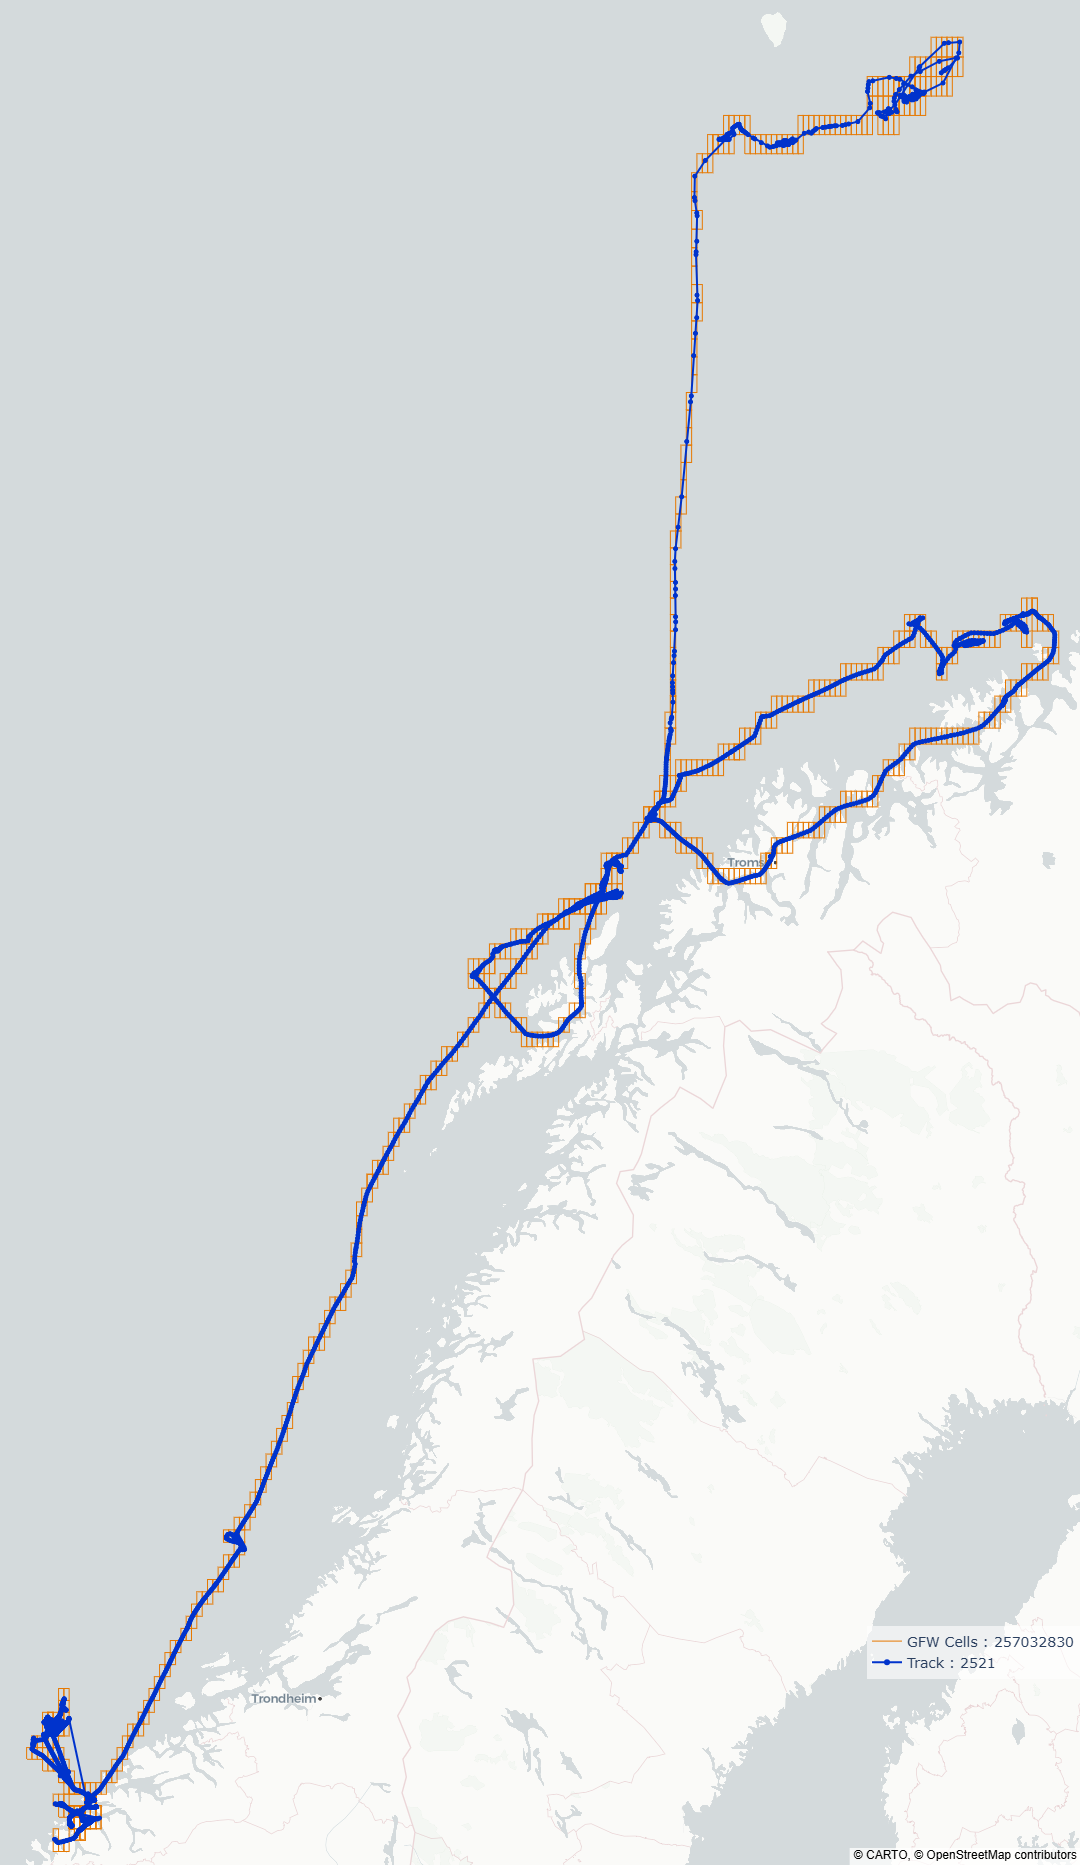

In [36]:
res = 0.1

# Remove unnecessary months
df2bis = df2[df2['month'].isin(df1['month'])]
df1bis = df1[df1['track_id'].isin(track_ids)]

lats = df1bis[col_lat_astd].values
lons = df1bis[col_lon_astd].values

fig = go.Figure()

#GFW plot grids
lons_all = []
lats_all = []

for _, row in df2bis.iterrows():
    lon0 = row[col_lon_gfw]
    lat0 = row[col_lat_gfw]

    lons_all += [lon0, lon0+res, lon0+res, lon0, lon0, None]
    lats_all += [lat0, lat0, lat0+res, lat0+res, lat0, None]


fig.add_trace(go.Scattermap(
    lon=lons_all,
    lat=lats_all,
    mode="lines",
    line=dict(color="rgba(230, 120, 0, 1)", width=1),
    name=f"GFW Cells : {mmsi}"
))


fig.add_trace(go.Scattermap(
    lon=lons,
    lat=lats,
    mode="lines+markers",
    line=dict(color="#0033cc", width=2),
    name=f"Track : {track_ids[0] if len(track_ids)==1 else track_ids}"
))


pad = 0.5

lat_mean = df2bis[col_lat_gfw].mean()

lon_range = df2bis[col_lon_gfw].max() - df2bis[col_lon_gfw].min()
lat_range = df2bis[col_lat_gfw].max() - df2bis[col_lat_gfw].min()

lon_range_corr = lon_range * np.cos(np.radians(lat_mean))

aspect_ratio = lon_range_corr / lat_range

width = 1080
height = int(width / aspect_ratio)

bypad_height = height / lat_range

height += (bypad_height * pad)

fig.update_layout(
    autosize=False,
    width=width,
    height=height,
    map=dict(
        style="carto-positron",
        bounds=dict(
            west=df2bis[col_lon_gfw].min() - pad,
            east=df2bis[col_lon_gfw].max() + pad,
            south=df2bis[col_lat_gfw].min() - pad,
            north=df2bis[col_lat_gfw].max() + pad
        ),
        center = dict(
            lon=(df2bis[col_lon_gfw].min() + df2bis[col_lon_gfw].max()) / 2,
            lat=(df2bis[col_lat_gfw].min() + df2bis[col_lat_gfw].max()) / 2
        ),
    ),
    legend=dict(
        orientation="v",
        x=1,
        y=0.1,
        xanchor="right",
        yanchor="bottom",
        bgcolor="rgba(255,255,255,0.6)"
    ),
    font=dict(size=14),
    margin=dict(l=0, r=0, t=0, b=0),
)

# tb.export_figure(fig, f"GFW2ASTD_{mmsi}.html")
pio.write_image(fig, f"outputs/{mmsi}_{track_ids}.pdf", format="pdf")

img_bytes = pio.to_image(fig, format="png")
display(Image(img_bytes, retina=True))

# pio.renderers.default = "browser"
# pio.renderers.default = "notebook"
# fig.show() #Show interactive map

## Zoomed In by month

In [153]:
res = 0.1

# Remove unnecessary months
df2bis = df2[df2['month'].isin(df1['month'])]
df1bis = df1[df1['track_id'].isin(track_ids)]

months = pd.to_datetime(pd.concat([df1bis['month'], df2bis['month']])).dt.strftime("%Y-%m").unique()
month_colors = px.colors.qualitative.Dark24
color_map = {m: month_colors[i % len(month_colors)] for i, m in enumerate(sorted(months))}

fig_zoom = go.Figure()

for (month, track_id), df_month in df1bis.groupby(['month', 'track_id']):
    df_month = df_month.sort_values('date_time_utc')

    fig_zoom.add_trace(go.Scattermap(
        lon=df_month[col_lon_astd],
        lat=df_month[col_lat_astd],
        mode="lines+markers",
        name=f"Track : {track_id} - {month}",
        line=dict(color=color_map[month], width=2),
        marker=dict(size=6),
        customdata=df_month['date_time_utc'],
        hovertemplate=(
            "Date: %{customdata}<br>"
            "Lat: %{lat}<br>"
            "Lon: %{lon}<extra></extra>"
        )
    ))



lons_all = []
lats_all = []

for _, row in df2bis.iterrows():
    lon0 = row[col_lon_gfw]
    lat0 = row[col_lat_gfw]

    lons_all += [lon0, lon0 + res, lon0 + res, lon0, lon0, None]
    lats_all += [lat0, lat0, lat0 + res, lat0 + res, lat0, None]


fig_zoom.add_trace(go.Scattermap(
    lon=lons_all,
    lat=lats_all,
    mode="lines",
    line=dict(color="rgba(230, 120, 0, 1)", width=1),
    name=f"GFW Cells : {mmsi}"
))

def set_layout(zoom, center, x, xanchor):
    _center = dict(
                lon=(df2bis[col_lon_gfw].min() + df2bis[col_lon_gfw].max()) / 2,
                lat=(df2bis[col_lat_gfw].min() + df2bis[col_lat_gfw].max()) / 2
            )

    if center != "all":
        center = [center] if type(center) != list else center
        mask = df2bis['month'].isin(center)
        subset = df2bis.loc[mask, [col_lon_gfw, col_lat_gfw]]

        _center = {
            "lon": (subset[col_lon_gfw].min() + subset[col_lon_gfw].max()) / 2,
            "lat": (subset[col_lat_gfw].min() + subset[col_lat_gfw].max()) / 2
        }

    fig_zoom.update_layout(
        map=dict(
            style="carto-positron",
            zoom=zoom,
            center = _center
        ),
        legend=dict(
            orientation="v",
            x=x,
            y=0.1,
            xanchor=xanchor,
            yanchor="bottom",
            bgcolor="rgba(255,255,255,0.6)"
        ),
        margin=dict(l=0, r=0, t=0, b=0)
    )

set_layout(4, "all", 1, "right")

pio.renderers.default = "browser"
# pio.renderers.default = "notebook"
fig_zoom.show() #Show interactive map

### Export image with specified zoom

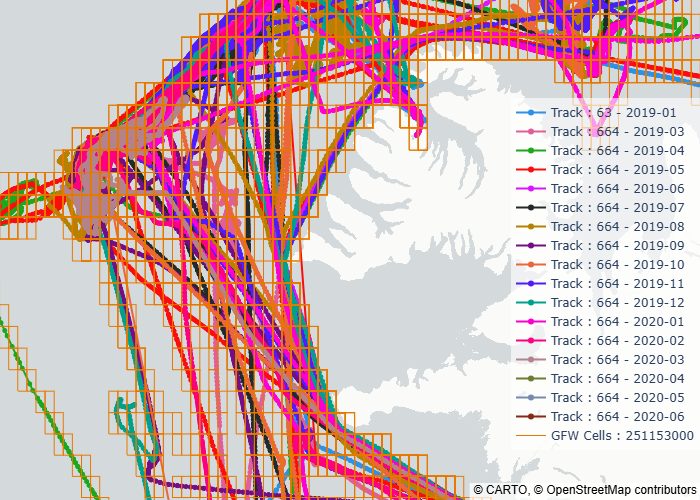

In [156]:
set_layout(6, "2019-12", 1, "right")

img_bytes = pio.to_image(fig_zoom, format="png")
display(Image(img_bytes, retina=True))

pio.write_image(fig_zoom, f"outputs/{mmsi}_{track_ids}_ZOOM.pdf", format="pdf")

## Generate Video

In [17]:
df2['date'] = pd.to_datetime(df2['date'], utc=True)
df1['date'] = pd.to_datetime(df1['date'], utc=True)

remerged = df2.merge(df1, on=["grid_lon", "grid_lat", "date", "month"], how="inner")

display(remerged)

,date,cell_ll_lat,cell_ll_lon,mmsi,hours,fishing_hours,month,grid_lon,grid_lat,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,track_id
0,2019-01-01 00:00:00+00:00,64.1,-22.0,251153000,24.0527,0.0,2019-01,-220,641,1768,2019-01-01 00:02:08+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,1.836830,161,-21.940008,64.154335,63
1,2019-01-01 00:00:00+00:00,64.1,-22.0,251153000,24.0527,0.0,2019-01,-220,641,1768,2019-01-01 00:04:48+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,0.747702,370,-21.940039,64.154327,63
2,2019-01-01 00:00:00+00:00,64.1,-22.0,251153000,24.0527,0.0,2019-01,-220,641,1768,2019-01-01 00:10:58+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,0.782013,190,-21.940025,64.154327,63
3,2019-01-01 00:00:00+00:00,64.1,-22.0,251153000,24.0527,0.0,2019-01,-220,641,1768,2019-01-01 00:14:09+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,0.444168,179,-21.940029,64.154320,63
4,2019-01-01 00:00:00+00:00,64.1,-22.0,251153000,24.0527,0.0,2019-01,-220,641,1768,2019-01-01 00:17:08+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,0.911275,182,-21.940035,64.154320,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197127,2020-06-03 00:00:00+00:00,64.1,-21.9,251153000,13.6480,0.0,2020-06,-219,641,1557,2020-06-03 13:22:54+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,4.800000,290,-21.837370,64.138374,664
197128,2020-06-03 00:00:00+00:00,64.1,-21.9,251153000,13.6480,0.0,2020-06,-219,641,1557,2020-06-03 13:24:15+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,1.921000,81,-21.837360,64.138390,664
197129,2020-06-03 00:00:00+00:00,64.1,-21.9,251153000,13.6480,0.0,2020-06,-219,641,1557,2020-06-03 13:28:56+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,1.340000,281,-21.837353,64.138382,664
197130,2020-06-03 00:00:00+00:00,64.1,-21.9,251153000,13.6480,0.0,2020-06,-219,641,1557,2020-06-03 13:30:24+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,1.541000,88,-21.837345,64.138397,664


In [18]:
select_subset = False

if select_subset:
    # get gfw samples
    # work = (
    #     merged
    #     .groupby(['mmsi', 'date'], group_keys=False)
    #     .sample(10, random_state=42)
    # )

    work = (
        remerged
        .sort_values(['mmsi', 'date'])  # or include timestamp if you have one
        .groupby(['mmsi', 'date'], group_keys=False)
        .apply(lambda g: g if len(g) <= 50 else g.iloc[np.linspace(0, len(g)-1, 50, dtype=int)])
    )

    work.sort_index(inplace=True)

else:
    # or keep full data
    work = remerged.copy()

work.drop_duplicates(subset=['date', 'grid_lon', 'grid_lat'], inplace=True)
work.sort_values('date_time_utc', inplace=True)

In [19]:
work

,date,cell_ll_lat,cell_ll_lon,mmsi,hours,fishing_hours,month,grid_lon,grid_lat,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,track_id
0,2019-01-01 00:00:00+00:00,64.1,-22.0,251153000,24.0527,0.0,2019-01,-220,641,1768,2019-01-01 00:02:08+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,1.836830,161,-21.940008,64.154335,63
434,2019-01-02 00:00:00+00:00,64.1,-22.0,251153000,21.6997,0.0,2019-01,-220,641,1768,2019-01-02 00:02:37+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,0.563269,32,-21.940035,64.154327,63
823,2019-01-02 00:00:00+00:00,64.2,-22.1,251153000,0.3858,0.0,2019-01,-221,642,1768,2019-01-02 21:54:58+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,2569.363037,370,-22.027866,64.209892,63
831,2019-01-02 00:00:00+00:00,64.2,-22.2,251153000,0.1741,0.0,2019-01,-222,642,1768,2019-01-02 22:07:08+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,74.662788,11,-22.114897,64.234543,63
826,2019-01-02 00:00:00+00:00,64.2,-22.3,251153000,0.2463,0.0,2019-01,-223,642,1768,2019-01-02 22:19:20+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,61.534943,8,-22.201250,64.258240,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195297,2020-05-30 00:00:00+00:00,64.1,-21.9,251153000,23.9536,0.0,2020-05,-219,641,1103,2020-05-30 00:04:05+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,2.458000,298,-21.837357,64.138405,664
195709,2020-05-31 00:00:00+00:00,64.1,-21.9,251153000,24.0391,0.0,2020-05,-219,641,1103,2020-05-31 00:04:04+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,9.229000,361,-21.837463,64.138367,664
196122,2020-06-01 00:00:00+00:00,64.1,-21.9,251153000,24.0075,0.0,2020-06,-219,641,1557,2020-06-01 00:03:53+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,4.335000,368,-21.837351,64.138367,664
196536,2020-06-02 00:00:00+00:00,64.1,-21.9,251153000,24.0005,0.0,2020-06,-219,641,1557,2020-06-02 00:03:30+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,3.724000,224,-21.837368,64.138397,664


In [ ]:
df = work.copy()#work[work['date_time_utc']>="2020-12-20"].copy()
df['date_time_utc'] = df['date_time_utc'].dt.strftime("%Y-%m-%d %H:%M:%S")

fig, ax = plt.subplots()

# ax = plt.axes(projection=ccrs.PlateCarree())
# ax.add_image(cimgt.OSM(), 2)
# ax.coastlines()

lats = df[col_lat_astd].values
lons = df[col_lon_astd].values

#GFW plot grids
lons_all = []
lats_all = []

for _, row in df.iterrows():
    lon0 = row[col_lon_gfw]
    lat0 = row[col_lat_gfw]

    lons_all += [lon0, lon0+0.1, lon0+0.1, lon0, lon0, np.nan]
    lats_all += [lat0, lat0, lat0+0.1, lat0+0.1, lat0, np.nan]

zoom = 0

if zoom != 0:
    pad_lon = (lons.max() - lons.min()) / zoom
    pad_lat = (lats.max() - lats.min()) / zoom
else:
    ax.set_xlim(lons.min() - 0.3, lons.max() + 0.3)
    ax.set_ylim(lats.min() - 0.3, lats.max() + 0.3)
    # ax.set(xlim=[lons.min(), lons.max()], ylim=[lats.min(), lats.max()])

grid = ax.plot(lons_all[0], lats_all[0], "#e67800", label=f'GFW {mmsi}')[0]#, transform=ccrs.PlateCarree())[0]
line = ax.plot(lons[0], lats[0], "#0033cc", label=f'Track {track_ids[0] if len(track_ids)==1 else track_ids}')[0]#, transform=ccrs.PlateCarree())[0]
point = ax.plot(lons[0], lats[0], 'ro', label = 'Time')[0]#, transform=ccrs.PlateCarree())[0]
# line = ax.plot(lons[0], lats[0], label=f'Track')[0]

ax.set_xticks([])
ax.set_yticks([])
legend = ax.legend(loc='upper left')

plt.tight_layout()

def update(frame):
    point.set_label(f"{df['date_time_utc'].iloc[frame]}")

    # Position
    grid.set_data(lons_all[:(frame+1)*6], lats_all[:(frame+1)*6])
    line.set_data(lons[:frame+1], lats[:frame+1])
    point.set_data([lons[frame]], [lats[frame]])

    # Zoom and camera position
    # ax.set_xlim(lons[frame] - pad_lon, lons[frame] + pad_lon)
    # ax.set_ylim(lats[frame] - pad_lat, lats[frame] + pad_lat)

    legend.get_texts()[2].set_text(point.get_label())

    pbar.update(1)
    return line, point

pbar = tqdm(total=df.shape[0]+1)  # set total to expected number of calls

ani = animation.FuncAnimation(fig=fig, func=update, frames=df.shape[0])
ani.save(filename=f"videos/{mmsi}_{track_ids}_VIDEOFIX.mp4", writer="ffmpeg", fps=60, dpi=150, bitrate=2000)
plt.close('all')
pbar.close()